In [28]:
from pyrokinetics import Pyro, PyroScan
import os
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt

In [29]:
# Replace with path to your Gyrokinetic Simulations
GYRO_DIR  = Path("/mnt/data/Gyrokinetic_Simulations/")

In [30]:
cases = ["M1_A1_NE","R3","R4","S1_3"]
projects = ["scan_q","scan_shat","scan_beta"]
# cases = ["R3","R4"]
# projects = ["scan_beta"]

In [31]:
project_dict ={}
for project in projects:
    case_dict = {}
    for case in cases:
        print(f"Project: {project}, Case: {case}")
        json_path = Path(GYRO_DIR / Path(f"GS2/Runs/{project}/{case}/parameter_scan_GS2/pyroscan.json"))
        net_cdf_path = Path(GYRO_DIR / Path(f"GS2/Runs/{project}/{case}/parameter_scan_GS2/pyroscan.nc"))
        try:
            gs2_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
            try:
                gs2_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
                case_dict[case] = gs2_pyoscan
            except Exception as e:
                print(f"Error loading gk output for {project}/{case}: {e}")
                try:
                    gs2_pyoscan.load_gk_output()
                    gs2_pyoscan.gk_output.to_netcdf(net_cdf_path)
                    case_dict[case] = gs2_pyoscan
                except Exception as e:
                    print(f"Error loading gk output without netcdf for {project}/{case}: {e}")
        except Exception as e:
            print(f"Error loading pyroscan for {project}/{case}: {e}")
            continue
    project_dict[project] = case_dict

Project: scan_q, Case: M1_A1_NE


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/normalisation.py:941: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0060'. 
  warnings.warn(


Project: scan_q, Case: R3
Project: scan_q, Case: R4
Project: scan_q, Case: S1_3


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/pyro.py:1785: UserWarning: Explicitly set value of beta (0.09 beta_ref_ee_B0_pyroscan_base0063) is inconsistent with value from physical reference values (0.09609377161346086 beta_ref_ee_B0_pyroscan_base0063)
  warnings.warn(
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/normalisation.py:941: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0063'. 
  warnings.warn(


Project: scan_shat, Case: M1_A1_NE


...

Project: scan_shat, Case: R3
Project: scan_shat, Case: R4
Error loading gk output for scan_shat/R4: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/GS2/Runs/scan_shat/R4/parameter_scan_GS2/pyroscan.nc'
Error loading gk output without netcdf for scan_shat/R4: Unable to load any gk_output files in this scan
Project: scan_shat, Case: S1_3


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/pyroscan.py:800: UserWarning: Unable to load gk_output for /mnt/data/Gyrokinetic_Simulations/GS2/Runs/scan_shat/R4/parameter_scan_GS2/ky0.100_shat-0.250/gs2.in [ValueError: File /mnt/data/Gyrokinetic_Simulations/GS2/Runs/scan_shat/R4/parameter_scan_GS2/ky0.100_shat-0.250/gs2.out.nc not found.]
  warnings.warn(
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/pyroscan.py:800: UserWarning: Unable to load gk_output for /mnt/data/Gyrokinetic_Simulations/GS2/Runs/scan_shat/R4/parameter_scan_GS2/ky0.100_shat-0.056/gs2.in [ValueError: File /mnt/data/Gyrokinetic_Simulations/GS2/Runs/scan_shat/R4/parameter_scan_GS2/ky0.100_shat-0.056/gs2.out.nc not found.]
  warnings.warn(
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/pyroscan.py:800: UserWarning: U

Project: scan_beta, Case: M1_A1_NE


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/normalisation.py:941: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0068'. 
  warnings.warn(


Project: scan_beta, Case: R3
Project: scan_beta, Case: R4
Project: scan_beta, Case: S1_3
Error loading pyroscan for scan_beta/S1_3: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/GS2/Runs/scan_beta/S1_3/parameter_scan_GS2/pyroscan.json'


In [ ]:
tglf_versions = ["TGLF_sat2","tglf_v1_sat2","tglf_v2","tglf_v3","tglf_v4","tglf_najlaoui_emS"]
name_dict = {
    "TGLF_sat2":"Default",
    "tglf_v1_sat2": "V1",
    "tglf_v2": "V2",
    "tglf_v3": "V3",
    "tglf_v4": "V4",
    "tglf_najlaoui_emS": "emS",

}
tglf_project_dict ={}
for project in projects:
    case_dict = {}
    for case in cases:
        version_dict = {}
        for version in tglf_versions:
            print(f"Project: {project}, Case: {case}")
            json_path = Path(GYRO_DIR / Path(f"TGLF/Runs/{project}/{case}/parameter_scan_{version}/pyroscan.json"))
            net_cdf_path = Path(GYRO_DIR / Path(f"TGLF/Runs/{project}/{case}/parameter_scan_{version}/pyroscan.nc"))
            try:
                tglf_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
                try:
                    tglf_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
                    version_dict[name_dict[version]] = tglf_pyoscan
                except Exception as e:
                    print(f"Error loading gk output for {project}/{case}/{version}: {e}")
                    # try:
                    #     tglf_pyoscan.load_gk_output()
                    #     tglf_pyoscan.gk_output.to_netcdf(net_cdf_path)
                    #     version_dict[version] = tglf_pyoscan
                    # except Exception as e:
                    #     print(f"Error loading gk output without netcdf for {project}/{case}/{version}: {e}")
            except Exception as e:
                print(f"Error loading pyroscan for {project}/{case}/{version}: {e}")
                continue
        case_dict[case] = version_dict
    tglf_project_dict[project] = case_dict

Project: scan_q, Case: M1_A1_NE
Project: scan_q, Case: M1_A1_NE
Project: scan_q, Case: M1_A1_NE
Project: scan_q, Case: M1_A1_NE
Project: scan_q, Case: M1_A1_NE
Error loading pyroscan for scan_q/M1_A1_NE/tglf_najlaoui_emS: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/scan_q/M1_A1_NE/parameter_scan_tglf_najlaoui_emS/pyroscan.json'
Project: scan_q, Case: R3
Project: scan_q, Case: R3
Project: scan_q, Case: R3
Project: scan_q, Case: R3
Project: scan_q, Case: R3
Error loading pyroscan for scan_q/R3/tglf_najlaoui_emS: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/scan_q/R3/parameter_scan_tglf_najlaoui_emS/pyroscan.json'
Project: scan_q, Case: R4
Project: scan_q, Case: R4
Project: scan_q, Case: R4
Project: scan_q, Case: R4
Project: scan_q, Case: R4
Error loading pyroscan for scan_q/R4/tglf_najlaoui_emS: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/scan_q/R4/parameter_scan_tglf_najlaoui

In [ ]:
tglf_versions = ["Default","V1","V2","V3","V4","emS"]

In [34]:
# Plot Eigenfunction Differences between GS2, tglf_default and TGLF_v1, and TGLF_v2

project = "scan_beta"
case = "R3"
ky = 0.5
beta = 0.10
reference_q = 0.036


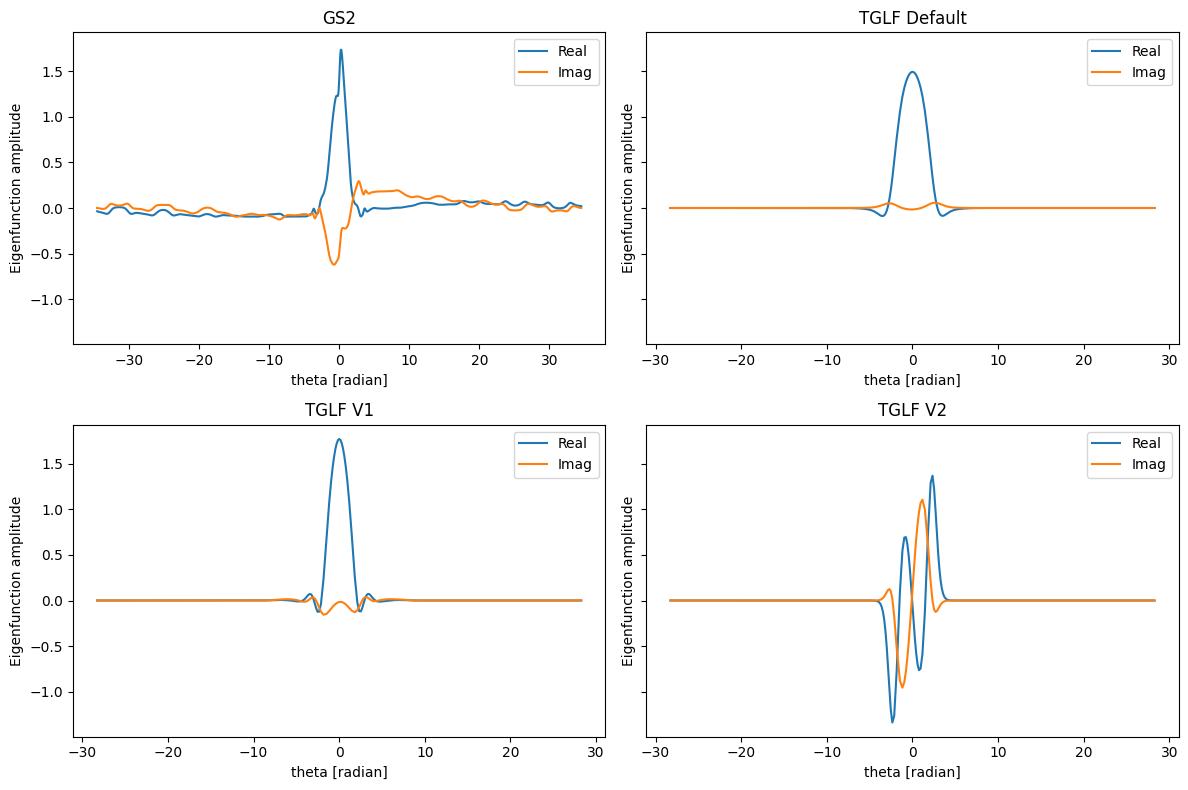

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

labels = ["GS2", "TGLF Default", "TGLF V3", "TGLF V4"]

def get_eig(data, is_gs2=False):
    sel = data.gk_output["eigenfunctions"].sel(ky=ky, method="nearest").sum(dim="field").sel(beta=beta)
    if not is_gs2:
        sel = sel.sel(mode=0)
    return np.real(sel), np.imag(sel)

real_gs2, imag_gs2 = get_eig(project_dict[project][case], is_gs2=True)
real_def, imag_def = get_eig(tglf_project_dict[project][case]["Default"])
real_v1,  imag_v1  = get_eig(tglf_project_dict[project][case]["V3"])
real_v2,  imag_v2  = get_eig(tglf_project_dict[project][case]["V4"])

data_pairs = [
    (real_gs2, imag_gs2),
    (real_def, imag_def),
    (real_v1,  imag_v1),
    (real_v2,  imag_v2),
]

for ax, (real, imag), label in zip(axes.flat, data_pairs, labels):
    real.plot(ax=ax, label="Real")
    imag.plot(ax=ax, label="Imag")
    ax.set_ylabel("Eigenfunction amplitude")
    ax.set_title(label)
    ax.legend()

fig.tight_layout()
ky_actual = float(
    project_dict[project][case].gk_output["growth_rate"]
    .sel(ky=ky, method="nearest")
    .ky
)

path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
plt.savefig(f"{path}/Eigenfunction Comparison— {case}, ky={ky_actual:.3f}, beta = {beta}.png", dpi=300)


In [36]:
# GYRO_DATA = Path("/mnt/data/Gyrokinetic_Simulations")
# models_path = "/home/Felix/Documents/Physics_Work/Project_Codes/GP-MODELS/0.0.3/"  # This is using the 3000 data point model as opposed to the 100000 data point model for testing purposes


# models = [
#     "growth_rate",
#     "mode_frequency_log",
#     "kperp2_phi_log",
#     "kperp2_apa_log",
#     "kperp2_bpar_log",
#     "totIonFlux_log",
#     "totElecFlux_log",
#     "totPartFlux_log",
#     "apa_phi_log",
#     "bpar_phi_log",
# ]

# from pyrokinetics.diagnostics.gs2_gp import gs2_gp

In [37]:
# project = "scan_q"
# case = "S1"

# Gaussian_Model =gs2_gp(pyro=project_dict[project][case], models_path=models_path, models=models)

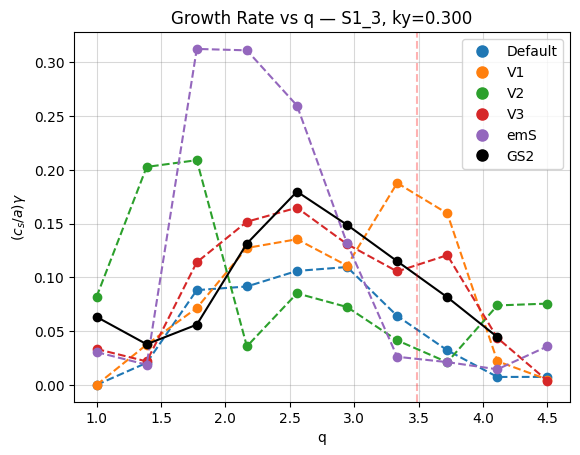

In [38]:

# Plot Q scan
project = "scan_q"
case = "S1_3"
ky = 0.3
reference_q = 3.49


for tglf in tglf_versions:
    (tglf_project_dict[project][case][tglf]
        .gk_output["growth_rate"]
        .sel(ky=ky, method="nearest")
        .sel(mode=0)
        .plot(label=tglf, marker="o", linestyle="--"))

gs2_growth_rate = (project_dict[project][case]
    .gk_output["growth_rate"]
    .sel(ky=ky, method="nearest"))
gs2_growth_rate_tolerance = (project_dict[project][case]
    .gk_output["growth_rate_tolerance"]
    .sel(ky=ky, method="nearest"))
gs2_growth_rate = gs2_growth_rate.where(gs2_growth_rate_tolerance < 0.3)

# Gaussian_Model = gs2_gp(pyro=project_dict[project][case],
#                        models_path=models_path, models=models)
# gp = (Gaussian_Model.gk_output["growth_rate"]
#     .sel(output="value")
#     .sel(ky=ky, method="nearest"))
# gp_max = (Gaussian_Model.gk_output["growth_rate"]
#     .sel(output="max_value")
#     .sel(ky=ky, method="nearest"))
# gp_min = (Gaussian_Model.gk_output["growth_rate"]
#     .sel(output="min_value")
#     .sel(ky=ky, method="nearest"))

# gp.plot(label="GS2-GP", marker="o", linestyle="--")
# plt.fill_between(gp["q"].values, gp_min.values, gp_max.values, color="blue", alpha=0.2, label="GS2-GP Uncertainty")
gs2_growth_rate.plot(label="GS2", color="black", marker="o")

ky_actual = float(
    project_dict[project][case].gk_output["growth_rate"]
    .sel(ky=ky, method="nearest")
    .ky
)
plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

plt.title(f"Growth Rate vs q — {case}, ky={ky_actual:.3f}")
#plt.title("")
plt.xlabel("q")
plt.ylabel(r"$(c_s/a) \gamma$")
plt.grid(alpha=0.3, color='grey')
from matplotlib.lines import Line2D

handles, labels = plt.gca().get_legend_handles_labels()
dot_handles = [
    Line2D([], [], color=h.get_color(), marker="o", linestyle="none", markersize=8)
    for h in handles
]
plt.legend(dot_handles, labels)
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
#plt.savefig(f"{path}/Growth Rate vs q — {case}, ky={ky_actual:.3f}.png", dpi=300)



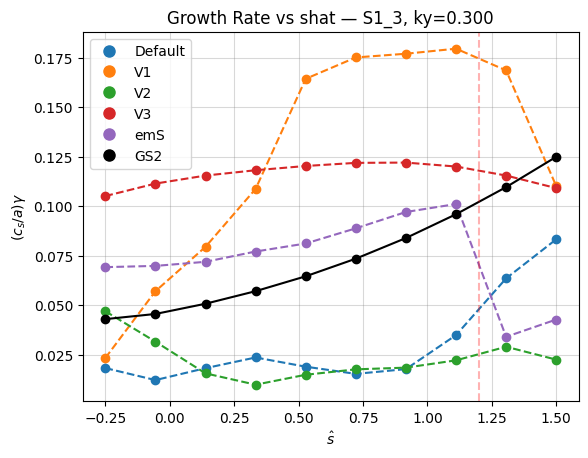

In [39]:
from matplotlib import pyplot as plt
# Plot shat scan
project = "scan_shat"
case = "S1_3"
ky = 0.3
reference_q = 1.2


for tglf in tglf_versions:
    tglf_project_dict[project][case][tglf].gk_output["growth_rate"].sel(ky =ky,method = "nearest").sel(mode =0).plot(label = tglf,marker = "o",linestyle = "--")

gs2_growth_rate = project_dict[project][case].gk_output["growth_rate"].sel(ky =ky,method = "nearest")
gs2_growth_rate_tolerance = project_dict[project][case].gk_output["growth_rate_tolerance"].sel(ky =ky,method = "nearest")
gs2_growth_rate = gs2_growth_rate.where(gs2_growth_rate_tolerance<0.3)
gs2_growth_rate.plot(label = "GS2", color = "black",marker = "o")
ky_actual = float(
    project_dict[project][case].gk_output["growth_rate"]
    .sel(ky=ky, method="nearest")
    .ky
)

plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")


plt.title(f"Growth Rate vs shat — {case}, ky={ky_actual:.3f}")
plt.xlabel(r"$\hat{s}$")
plt.ylabel(r"$(c_s/a) \gamma$")
plt.grid(alpha=0.3, color='grey')
from matplotlib.lines import Line2D

handles, labels = plt.gca().get_legend_handles_labels()
dot_handles = [
    Line2D([], [], color=h.get_color(), marker="o", linestyle="none", markersize=8)
    for h in handles
]
plt.legend(dot_handles, labels)
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
#plt.savefig(f"{path}/Growth Rate vs shat — {case}, ky={ky_actual:.3f}.png", dpi=300)



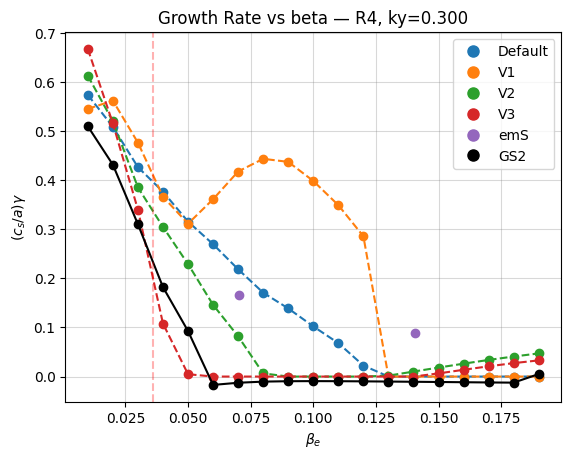

In [58]:
from matplotlib import pyplot as plt
# Plot shat scan
project = "scan_beta"
case = "R4"
ky = 0.3
reference_q = 0.036


for tglf in tglf_versions:
    tglf_project_dict[project][case][tglf].gk_output["growth_rate"].sel(ky =ky,method = "nearest").sel(mode =0).plot(label = tglf,marker = "o",linestyle = "--")

gs2_growth_rate = project_dict[project][case].gk_output["growth_rate"].sel(ky =ky,method = "nearest")
gs2_growth_rate_tolerance = project_dict[project][case].gk_output["growth_rate_tolerance"].sel(ky =ky,method = "nearest")
#gs2_growth_rate = gs2_growth_rate.where(gs2_growth_rate_tolerance<0.1)
gs2_growth_rate.plot(label = "GS2", color = "black",marker = "o")
ky_actual = float(
    project_dict[project][case].gk_output["growth_rate"]
    .sel(ky=ky, method="nearest")
    .ky
)

plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

plt.title(f"Growth Rate vs beta — {case}, ky={ky_actual:.3f}")
plt.xlabel(r"$\beta_e$")
plt.ylabel(r"$(c_s/a) \gamma$")
plt.grid(alpha=0.3, color='grey')
from matplotlib.lines import Line2D

handles, labels = plt.gca().get_legend_handles_labels()
dot_handles = [
    Line2D([], [], color=h.get_color(), marker="o", linestyle="none", markersize=8)
    for h in handles
]
plt.legend(dot_handles, labels)
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
#plt.savefig(f"{path}/Growth Rate vs beta — {case}, ky={ky_actual:.3f}.png", dpi=300)

In [41]:
tglf_project_dict["scan_beta"]["R3"]["emS"].gk_output["growth_rate"].isel(ky=4)

Magnitude,[[0.01938 0.01156] [0.036155 0.03326] [0.14227 0.047095] [0.20023 0.054098] [0.23188 0.05753] [0.2503 0.060391] [0.22973 0.061175] [0.22821 0.063529] [0.22051 0.065569] [0.206 0.066532] [0.18287 0.06622] [0.1457 0.064594] [0.084145 0.061686] [0.061003 0.05785] [0.061326 0.057331] [0.061622 0.057266] [0.062616 0.057079] [0.06269 0.05686] [0.062693 0.056479]]
Units,vref_nrl/lref_minor_radius


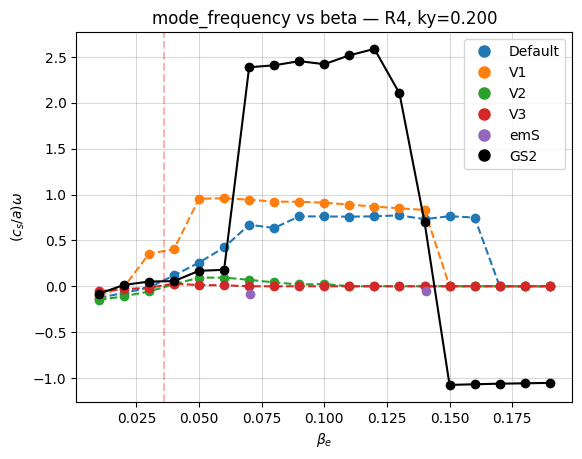

In [56]:
from matplotlib import pyplot as plt
# Plot shat scan
project = "scan_beta"
case = "R4"
ky = 0.2
reference_q = 0.036


for tglf in tglf_versions:
    tglf_project_dict[project][case][tglf].gk_output["mode_frequency"].sel(ky =ky,method = "nearest").sel(mode =0).plot(label = tglf,marker = "o",linestyle = "--")

gs2_mode_frequency = project_dict[project][case].gk_output["mode_frequency"].sel(ky =ky,method = "nearest")
gs2_mode_frequency_tolerance = project_dict[project][case].gk_output["growth_rate_tolerance"].sel(ky =ky,method = "nearest")
#gs2_mode_frequency = gs2_mode_frequency.where(gs2_mode_frequency_tolerance<0.1)
gs2_mode_frequency.plot(label = "GS2", color = "black",marker = "o")
ky_actual = float(
    project_dict[project][case].gk_output["mode_frequency"]
    .sel(ky=ky, method="nearest")
    .ky
)

plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

plt.title(f"mode_frequency vs beta — {case}, ky={ky_actual:.3f}")
plt.xlabel(r"$\beta_e$")
plt.ylabel(r"$(c_s/a) \omega$")
plt.grid(alpha=0.3, color='grey')
from matplotlib.lines import Line2D

handles, labels = plt.gca().get_legend_handles_labels()
dot_handles = [
    Line2D([], [], color=h.get_color(), marker="o", linestyle="none", markersize=8)
    for h in handles
]
plt.legend(dot_handles, labels)
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
#plt.savefig(f"{path}/mode_frequency vs beta — {case}, ky={ky_actual:.3f}.png", dpi=300)

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

_SCAN_LABELS = {
    "beta": r"$\beta_e$",
    "q": r"$q$",
    "shat": r"$\hat{s}$",
    "ky": r"$k_y$",
}
_FIELD_SYM = {"growth_rate": r"\gamma", "mode_frequency": r"\omega"}


def _difference_grid(gs2_output, tglf_output, field, metric, scan_param, mode):
    """Return (ky, par, diff2d, scan_param) for one GS2/TGLF pair."""
    gr_gs2 = gs2_output[field]
    gr_tglf = tglf_output[field]
    if "mode" in gr_tglf.dims:
        gr_tglf = gr_tglf.sel(mode=mode)

    if scan_param is None:
        other = [d for d in gr_gs2.dims if d != "ky"]
        if len(other) != 1:
            raise ValueError(
                f"Could not auto-detect scan_param from dims {gr_gs2.dims}; "
                "pass scan_param explicitly."
            )
        scan_param = other[0]

    # Align TGLF onto the GS2 grid so the subtraction is well defined
    gr_tglf = gr_tglf.interp(ky=gr_gs2["ky"], **{scan_param: gr_gs2[scan_param]})

    gr_gs2 = gr_gs2.transpose("ky", scan_param)
    gr_tglf = gr_tglf.transpose("ky", scan_param)

    if metric == "absolute":
        diff = gr_tglf.values - gr_gs2.values
    elif metric == "relative":
        diff = (gr_tglf.values - gr_gs2.values) / np.abs(gr_gs2.values)
    else:
        raise ValueError("metric must be 'absolute' or 'relative'")

    return gr_gs2["ky"].data, gr_gs2[scan_param].data, diff, scan_param


def plot_field_difference(gs2_output, tglf_outputs,
                          field="growth_rate",
                          metric="absolute",
                          scan_param=None,
                          mode=0,
                          vmax=None,
                          vmax_quantile=1.0,
                          cmap="seismic",
                          axes=None,
                          savefig=None):
    """
    Heatmap(s) of GS2-vs-TGLF difference in a linear field over
    (ky, <scan parameter>), one panel per TGLF version with a shared,
    symmetric colour scale.

        plot_field_difference(
            project_dict[project][case].gk_output,
            {v: tglf_project_dict[project][case][v].gk_output
             for v in tglf_versions},
        )

    Parameters
    ----------
    gs2_output : PyroScanGKOutput
        Ground-truth ``.gk_output``.
    tglf_outputs : mapping or sequence
        ``{label: gk_output}`` (or a single gk_output / list of them).
    field : str
        "growth_rate" or "mode_frequency".
    metric : {"absolute", "relative"}
        absolute -> Δ = tglf - gs2;  relative -> Δ / |gs2|.
    scan_param : str or None
        Scan axis name; auto-detected as the non-ky dim if None.
    mode : int
        Mode index selected from each TGLF output.
    vmax : float or None
        Symmetric colour limit. If None it is derived from the data across
        *all* versions (see vmax_quantile).
    vmax_quantile : float in (0, 1]
        Quantile of |Δ| (pooled over every version) used for the auto limit.
        1.0 = exact max; 0.98 clips a few outliers so the bulk has contrast.
    """

    # Normalise input to an ordered {label: output} dict
    if hasattr(tglf_outputs, "items"):
        items = list(tglf_outputs.items())
    elif isinstance(tglf_outputs, (list, tuple)):
        items = [(f"tglf {i}", o) for i, o in enumerate(tglf_outputs)]
    else:
        items = [("tglf", tglf_outputs)]

    # Compute every difference grid once
    grids = []
    for label, out in items:
        ky, par, diff, scan_param = _difference_grid(
            gs2_output, out, field, metric, scan_param, mode
        )
        grids.append((label, ky, par, diff))

    # Shared symmetric colour scale across all versions
    if vmax is None:
        pooled = np.abs(np.concatenate([g[3].ravel() for g in grids]))
        pooled = pooled[np.isfinite(pooled)]
        vmax = (np.quantile(pooled, vmax_quantile) if pooled.size
                else 1.0) or 1.0
    norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    n = len(grids)
    if axes is None:
        fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 5),
                                 sharey=True, squeeze=False)
        axes = axes[0]
    else:
        axes = np.atleast_1d(axes)
        fig = axes[0].figure

    pcm = None
    for ax, (label, ky, par, diff) in zip(axes, grids):
        ky_grid, par_grid = np.meshgrid(ky, par, indexing="ij")
        pcm = ax.pcolormesh(ky_grid, par_grid, diff,
                            cmap=cmap, norm=norm, shading="auto")
        ax.set_title(label)
        ax.set_xlabel(_SCAN_LABELS.get("ky", "ky"))
    axes[0].set_ylabel(_SCAN_LABELS.get(scan_param, scan_param))

    sym = _FIELD_SYM.get(field, r"x")
    if metric == "absolute":
        clabel = rf"$\Delta {sym}$"
    else:
        clabel = rf"$\Delta {sym} / |{sym}_{{\mathrm{{GS2}}}}|$"
    cbar = fig.colorbar(pcm, ax=list(axes), orientation="horizontal",
                        location="top", fraction=0.05, pad=0.10)
    cbar.set_label(clabel, labelpad=6)
    if savefig is not None:
        os.makedirs(os.path.dirname(savefig), exist_ok=True)
        fig.savefig(savefig, bbox_inches="tight", dpi=150)
    return fig, axes




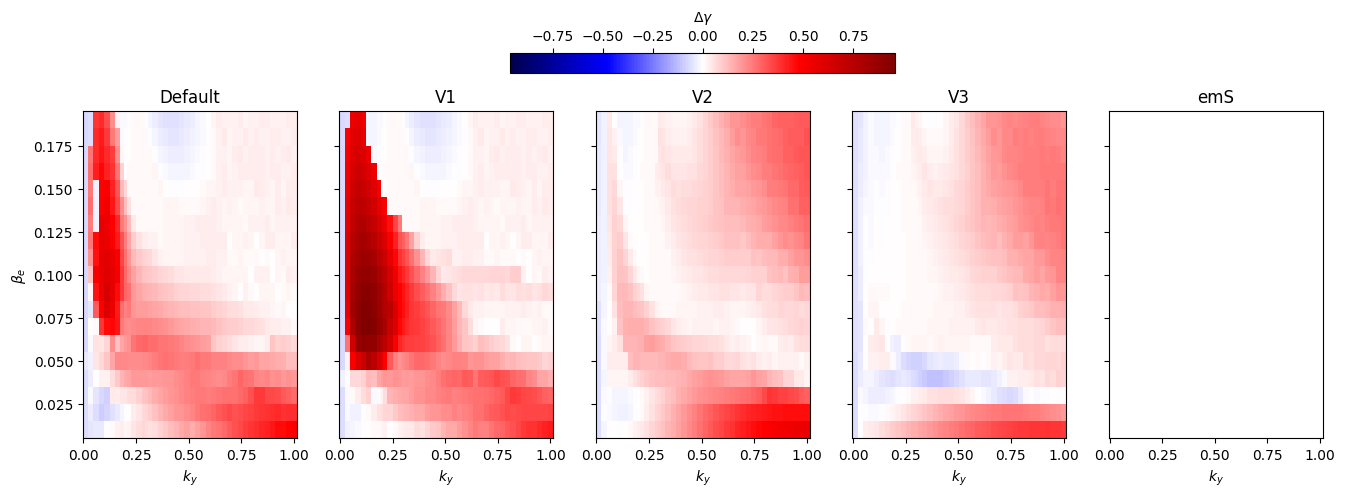

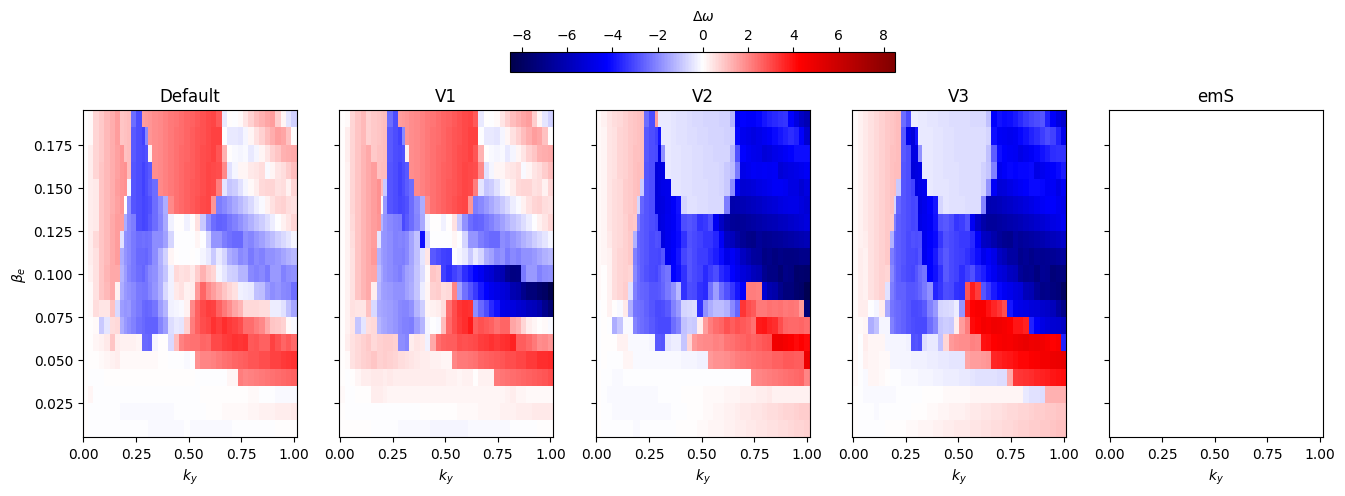

In [47]:
project, case = "scan_beta", "R4"
gs2 = project_dict[project][case].gk_output
tglfs = {v: tglf_project_dict[project][case][v].gk_output for v in tglf_versions}

for field in ["growth_rate", "mode_frequency"]:
    name = f"Absolute Error Colourmap {field} For {case}"
    location = f"../Plots/{project}/{case}/{name}.png"
    plot_field_difference(gs2, tglfs, field=field, savefig=location)


In [45]:
# ======================================================================
# Scalar error metrics for the GS2-vs-TGLF comparison.
# Reduces each (ky, scan) difference grid — the same grids drawn by the
# colourmap cell — to a few numbers per (case, version, field), so the
# "V2 agrees better" claim can be stated quantitatively.
#
# Needs _difference_grid (defined in the absolute-error colourmap cell)
# and the loaded project_dict / tglf_project_dict / tglf_versions.
# Iterates over whatever is currently loaded; uncomment the full
# cases/projects lists in the loader cells and re-run for the whole table.
# ======================================================================
import pandas as pd

try:
    _difference_grid
except NameError as exc:
    raise NameError("Run the absolute-error colourmap cell first — "
                    "_difference_grid is defined there.") from exc

FIELDS = ["growth_rate", "mode_frequency"]

# GS2 convergence filter: drop points whose eigenvalue is poorly converged
# (same growth_rate_tolerance < 0.3 cut as the line-plot cells). Applied to
# both fields, since the tolerance flags the whole linear solve.
APPLY_TOL_MASK = True
TOL_FIELD, TOL_MAX = "growth_rate_tolerance", 0.3


def _keep_mask(gs2_output, scan_param):
    if not APPLY_TOL_MASK:
        return None
    try:
        tol = gs2_output[TOL_FIELD]
    except KeyError:
        return None
    return tol.transpose("ky", scan_param).values < TOL_MAX


def _metrics(diff, gs2_vals, keep=None):
    d = np.asarray(diff, float)
    g = np.abs(np.asarray(gs2_vals, float))
    if keep is not None:
        d, g = d[keep], g[keep]
    d, g = d.ravel(), g.ravel()
    ok = np.isfinite(d)
    d, g = d[ok], g[ok]
    if d.size == 0:
        return dict(N=0, MAE=np.nan, RMSE=np.nan, nRMSE=np.nan,
                    bias=np.nan, max_abs=np.nan)
    rmse = np.sqrt(np.mean(d ** 2))
    peak = np.nanmax(g) if g.size else np.nan          # peak |GS2| over kept pts
    return dict(
        N=int(d.size),
        MAE=float(np.mean(np.abs(d))),                 # mean |tglf - gs2|
        RMSE=float(rmse),                              # root-mean-square error
        nRMSE=float(rmse / peak) if peak else np.nan,  # RMSE / peak|GS2|
        bias=float(np.mean(d)),                        # signed: + => over-predicts
        max_abs=float(np.max(np.abs(d))),              # worst-case point
    )


rows = []
for proj, case_dict in project_dict.items():
    for case, gs2_scan in case_dict.items():
        versions = tglf_project_dict.get(proj, {}).get(case, {})
        for version in [v for v in tglf_versions if v in versions]:
            for field in FIELDS:
                try:
                    _, _, diff, scan_param = _difference_grid(
                        gs2_scan.gk_output, versions[version].gk_output,
                        field=field, metric="absolute",
                        scan_param=None, mode=0,
                    )
                except Exception as e:
                    print(f"skip {proj}/{case}/{version}/{field}: {e}")
                    continue
                keep = _keep_mask(gs2_scan.gk_output, scan_param)
                gs2_vals = (gs2_scan.gk_output[field]
                            .transpose("ky", scan_param).values)
                rows.append(dict(project=proj, case=case, version=version,
                                 field=field, scan=scan_param,
                                 **_metrics(diff, gs2_vals, keep)))

metrics_df = pd.DataFrame(rows)
metrics_df["version"] = pd.Categorical(metrics_df["version"],
                                       tglf_versions, ordered=True)
metrics_df = metrics_df.sort_values(
    ["project", "case", "field", "version"]).reset_index(drop=True)

# Paper pivot: RMSE per (case, field), one column per TGLF version.
# Swap values="nRMSE" for the peak-normalised version (comparable across cases).
rmse_table = (metrics_df
              .pivot_table(index=["case", "field"], columns="version",
                           values="RMSE", observed=True)
              .reindex(columns=tglf_versions))

print(metrics_df.to_string(index=False, float_format=lambda x: f"{x:.4g}"))
print("\nRMSE by case/field:\n",
      rmse_table.to_string(float_format=lambda x: f"{x:.4g}"))
# LaTeX (needs \usepackage{multirow}; or .reset_index() for a flat table)
print("\n" + rmse_table.to_latex(float_format="%.3g"))

  project     case version          field scan   N     MAE    RMSE  nRMSE       bias  max_abs
scan_beta M1_A1_NE Default    growth_rate beta 463  0.9033   1.189  2.127     0.8607    2.294
scan_beta M1_A1_NE      V1    growth_rate beta 463  0.9714   1.304  2.332     0.9351    2.622
scan_beta M1_A1_NE      V2    growth_rate beta 463  0.9499    1.09   1.95     0.9437    2.356
scan_beta M1_A1_NE      V3    growth_rate beta 463  0.4243  0.4597 0.8222      0.397    0.717
scan_beta M1_A1_NE     emS    growth_rate beta 463    1.39   1.504  2.689       1.39    2.965
scan_beta M1_A1_NE Default mode_frequency beta 463   1.305   1.757  0.503    -0.8037    4.771
scan_beta M1_A1_NE      V1 mode_frequency beta 463   1.145   1.563 0.4474     -0.183    5.973
scan_beta M1_A1_NE      V2 mode_frequency beta 463   1.388   1.826 0.5229    -0.8223     4.87
scan_beta M1_A1_NE      V3 mode_frequency beta 463   1.453   2.107 0.6032     0.6854    6.974
scan_beta M1_A1_NE     emS mode_frequency beta 463   1.602  

/tmp/ipykernel_87659/1579326149.py:85: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  metrics_df["version"] = pd.Categorical(metrics_df["version"],
